In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pacificrm/skindiseasedataset/Readme.md
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/dermatofibroma-103.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/calcifying-epithelioma-7.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/epidermal-cyst-147.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/dermatofibroma-117.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/porokeratosis-70.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/skin-tags-polyps-44.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/acquired-digital-fibrokeratoma-3.jpeg
/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease/test/Benig

# SkinCare AI — Improved CNN with Dropout and Batch Normalization

## Objective

This notebook improves the simple CNN baseline by adding regularization techniques.

The main objectives are:
- Apply data augmentation to increase image diversity
- Add Batch Normalization to stabilize training
- Add Dropout to reduce overfitting
- Use EarlyStopping and ReduceLROnPlateau callbacks
- Evaluate the improved CNN on the test set
- Compare the results with the simple CNN baseline

This model aims to improve generalization compared to the first CNN baseline.

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [15]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [16]:
DATASET_PATH = "/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: True
Test exists: True


In [17]:
SELECTED_CLASSES = [
    "Acne",
    "Eczema",
    "Psoriasis",
    "Rosacea"
]

NUM_CLASSES = len(SELECTED_CLASSES)

print("Selected classes:", SELECTED_CLASSES)
print("Number of classes:", NUM_CLASSES)

Selected classes: ['Acne', 'Eczema', 'Psoriasis', 'Rosacea']
Number of classes: 4


## Data Preprocessing and Augmentation

In this notebook, data augmentation is applied to the training images.

Data augmentation helps reduce overfitting by creating modified versions of the original images, such as rotated, shifted, zoomed and flipped images.

The validation and test images are only rescaled, without augmentation, to evaluate the model on realistic data.

In [18]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
EPOCHS = 25

In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    subset="validation",
    shuffle=True,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    shuffle=False
)

Found 2143 images belonging to 4 classes.
Found 534 images belonging to 4 classes.
Found 293 images belonging to 4 classes.


In [20]:
print("Class indices:")
print(train_generator.class_indices)

Class indices:
{'Acne': 0, 'Eczema': 1, 'Psoriasis': 2, 'Rosacea': 3}


## Improved CNN Architecture

The improved CNN architecture includes:
- More convolutional blocks
- Batch Normalization after convolutional layers
- Dropout layers to reduce overfitting
- Dense layers for final classification

Batch Normalization helps stabilize and speed up training.  
Dropout randomly disables some neurons during training, which helps the model avoid memorizing the training data.

In [21]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.30),

    Conv2D(256, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.40),

    Flatten(),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.50),

    Dense(NUM_CLASSES, activation="softmax")
])

In [22]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,829,828 (37.50 MB)

 Trainable params: 9,828,356 (37.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

## Training Callbacks

Two callbacks are used:

- EarlyStopping: stops training when validation loss stops improving.
- ReduceLROnPlateau: reduces the learning rate when validation loss stagnates.

These callbacks help improve training stability and reduce overfitting.

In [23]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

## Model Training

The improved CNN is trained using augmented training images and validated on a separate validation subset.

In [24]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/25


I0000 00:00:1778966628.721275     148 service.cc:152] XLA service 0x7ee08800d170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778966628.721310     148 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778966628.721314     148 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778966629.513179     148 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-16 21:23:53.256430: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 21:23:53.406316: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/67 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.2109 - loss: 2.6096  

I0000 00:00:1778966640.031684     148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/67 ━━━━━━━━━━━━━━━━━━━━ 28s 575ms/step - accuracy: 0.2785 - loss: 2.3865

2026-05-16 21:24:13.224786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 21:24:13.374124: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


67/67 ━━━━━━━━━━━━━━━━━━━━ 77s 936ms/step - accuracy: 0.3325 - loss: 2.1369 - val_accuracy: 0.2397 - val_loss: 1.9905 - learning_rate: 1.0000e-04
Epoch 2/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 35s 522ms/step - accuracy: 0.4404 - loss: 1.6337 - val_accuracy: 0.3783 - val_loss: 4.3943 - learning_rate: 1.0000e-04
Epoch 3/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 34s 510ms/step - accuracy: 0.4581 - loss: 1.4487 - val_accuracy: 0.3783 - val_loss: 4.7087 - learning_rate: 1.0000e-04
Epoch 4/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.4743 - loss: 1.4479
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
67/67 ━━━━━━━━━━━━━━━━━━━━ 35s 516ms/step - accuracy: 0.4745 - loss: 1.4475 - val_accuracy: 0.3783 - val_loss: 6.0542 - learning_rate: 1.0000e-04
Epoch 5/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 35s 517ms/step - accuracy: 0.4752 - loss: 1.4579 - val_accuracy: 0.3783 - val_loss: 5.9177 - learning_rate: 3.0000e-05
Epoch 6/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 34s 514ms/step - accuracy: 0.5049 - 

## Learning Curves

The training and validation accuracy/loss curves are analyzed to evaluate model behavior and check whether overfitting has been reduced compared to the simple CNN baseline.

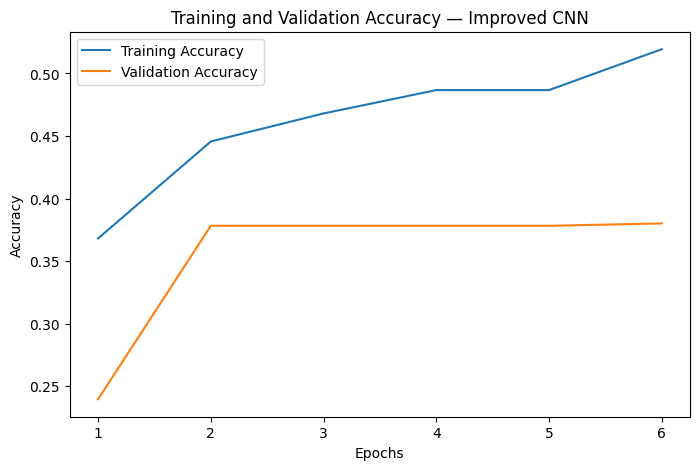

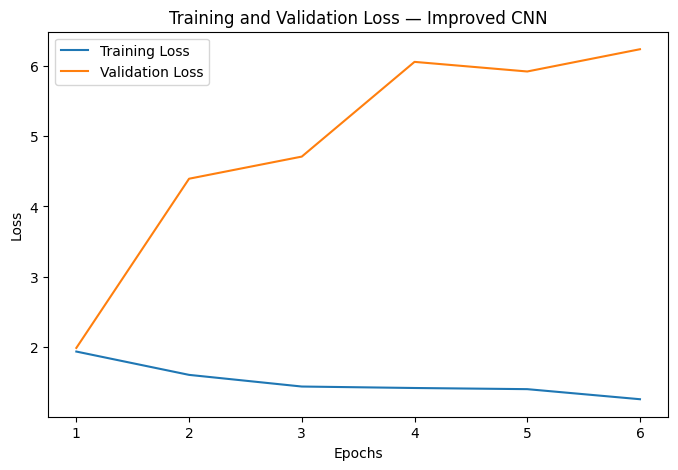

In [25]:
def plot_learning_curves(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title("Training and Validation Accuracy — Improved CNN")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title("Training and Validation Loss — Improved CNN")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_learning_curves(history)

In [26]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 365ms/step - accuracy: 0.4686 - loss: 1.2447
Test Loss: 1.9760229587554932
Test Accuracy: 0.24232082068920135


In [27]:
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

print("Predicted labels:", y_pred[:10])
print("True labels:", y_true[:10])

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step
Predicted labels: [0 0 1 0 0 0 0 1 0 0]
True labels: [0 0 0 0 0 0 0 0 0 0]


In [28]:
class_labels = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels
)

print(report)

              precision    recall  f1-score   support

        Acne       0.23      0.94      0.36        65
      Eczema       0.45      0.09      0.15       112
   Psoriasis       0.00      0.00      0.00        88
     Rosacea       0.00      0.00      0.00        28

    accuracy                           0.24       293
   macro avg       0.17      0.26      0.13       293
weighted avg       0.22      0.24      0.14       293



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


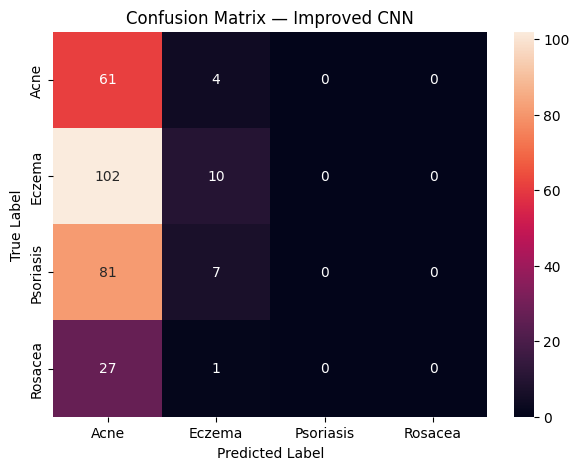

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix — Improved CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [30]:
model.save("/kaggle/working/improved_cnn_dropout_batchnorm.keras")
print("Improved CNN model saved successfully.")

Improved CNN model saved successfully.


## Comparison with Simple CNN Baseline

The simple CNN baseline achieved a test accuracy of approximately 51.88%.

This improved CNN introduces data augmentation, batch normalization, dropout and learning rate reduction in order to reduce overfitting and improve generalization.

The results of this model will be compared with the simple CNN baseline and with the MobileNetV2 transfer learning model in the final notebook.

## Results Interpretation

The improved CNN was designed to reduce overfitting observed in the simple CNN baseline.

Compared to the baseline model, this architecture includes data augmentation, Batch Normalization and stronger Dropout regularization.

After training, the learning curves should be analyzed to verify whether the gap between training accuracy and validation accuracy has decreased.

If the validation accuracy improves and the validation loss becomes more stable, this indicates better generalization.

The classification report and confusion matrix will help identify which skin disease classes are still difficult to distinguish.

This model will be compared with the MobileNetV2 transfer learning model in the next experiment.